## Case 1: Purely Data Driven Model

Neural Network fully trained from $t\in[0,1]$ on analytical solution

# 1. Environment Initialization
Set the seed for reproducibility with each iteration and establish hardware/mathematical precision.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import math

# Reproducibility
seed = 33
np.random.seed(seed) 
torch.manual_seed(seed)

# Concise device selection
device = "cuda" if torch.cuda.is_available() else "cpu"

# Set double precision (float64, rather than float32) for physics accuracy
torch.set_default_dtype(torch.float64)

print(f"Running on: {device}")

Running on: cpu


Parameter Set-up for  $\ m\frac{d^2 u}{dt^2} + \mu \frac{du}{dt} + k u = 0$

delta = 2.0
omega0 = 20.0
omega_d = 19.8997487421324


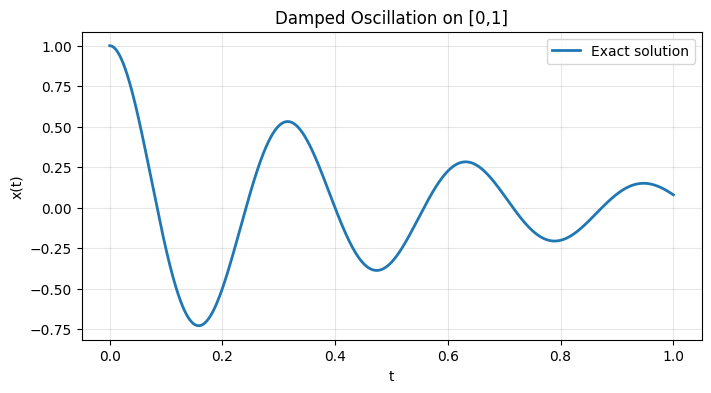

In [10]:
# Parameters
m = 0.09869604401089357
mu = 0.3947841760435743
k = (2 * math.pi) ** 2

# I.C.
x0 = 1.0 # position at t=0
v0 = 0.0 # velocity at t=0
# Time Domain
t0 = 0.0
tf = 1.0

delta = mu / (2*m)
omega0 = np.sqrt(k/m)
omega_d = np.sqrt(omega0**2 - delta**2)

print("delta =", delta)
print("omega0 =", omega0)
print("omega_d =", omega_d)

def exact_solution(t):
    return np.exp(-delta*t) * (np.cos(omega_d*t) + (delta/omega_d)*np.sin(omega_d*t))

def mse_np(y_pred, y_true):
    return np.mean((y_pred - y_true)**2)

def max_abs_error(y_pred, y_true):
    return np.max(np.abs(y_pred - y_true))

# Fine grid for testing and plotting
t_full = np.linspace(t0, tf, 2000)
x_full = exact_solution(t_full)

plt.figure(figsize=(8,4))
plt.plot(t_full, x_full, linewidth=2, label="Exact solution")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Damped Oscillation on [0,1]")
plt.grid(alpha=0.3)
plt.legend()
plt.show()





## 2. Building training data from analytical solution

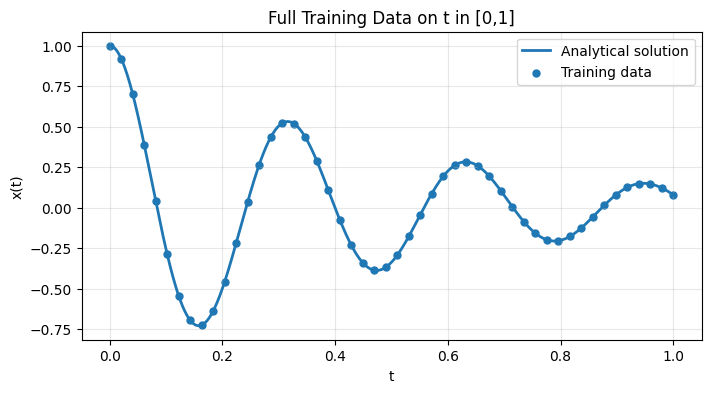

In [3]:
# Number of training points
n_train_np = 50

# Randomly sampled t-values from the domain [0, tf]
# Uses the seed set earlier to make this choice reproducible
t_train_np = np.linspace(t0, tf, n_train_np).reshape(-1, 1) # creates n_train x 1 vector of time stamps

# Get the corresponding 'x' values using formula
x_train_np = exact_solution(t_train_np)

# Convert NumPy arrays into PyTorch tensors

t_train = torch.tensor(t_train_np, dtype=torch.float64, device=device).reshape(-1, 1)
x_train = torch.tensor(x_train_np, dtype=torch.float64, device=device).reshape(-1, 1)

plt.figure(figsize=(8,4))
plt.plot(t_full, x_full, linewidth=2, label="Analytical solution")
plt.scatter(t_train_np, x_train_np, s=25, label="Training data")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Full Training Data on t in [0,1]")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 3. Train a purely data-driven model
No equation is provided, the DNN is given the set of 50 timestamps and produces estimates


In [4]:
import torch.nn as nn
class DNN(nn.Module):
    def __init__(self, hidden_units=64, hidden_layers=4):
        super().__init__()
        layers = [nn.Linear(1, hidden_units), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_units, hidden_units), nn.Tanh()]
        layers += [nn.Linear(hidden_units, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        return self.net(t)

def train_dnn(model, t_train, x_train, epochs=2000, lr=1e-3, print_every=500):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    loss_fn = nn.MSELoss()
    
    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        pred = model(t_train)
        loss = loss_fn(pred, x_train)
        loss.backward()
        optimizer.step()
        history.append(loss.item())
        
        if epoch == 1 or epoch % print_every == 0:
            print(f"Epoch {epoch:5d}/{epochs} | data loss = {loss.item():.8e}")
    return history

def predict(model, t):
    model.eval()
    t_tensor = torch.tensor(t, dtype=torch.float64, device=device).reshape(-1, 1)
    with torch.no_grad():
        pred = model(t_tensor)
    return pred.cpu().numpy().flatten()

model_case1 = DNN(hidden_units=64, hidden_layers=4)
history_case1 = train_dnn(model_case1, t_train, x_train, epochs=2000, lr=1e-3, print_every=500)



Epoch     1/2000 | data loss = 1.35068503e-01
Epoch   500/2000 | data loss = 2.45309083e-02
Epoch  1000/2000 | data loss = 1.16007791e-02
Epoch  1500/2000 | data loss = 3.23550363e-03
Epoch  2000/2000 | data loss = 1.25492911e-03


In [5]:
# Alternate code, does not print error

# class DNN(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(1, 64), nn.Tanh(),      # Input: Time (t)
#             nn.Linear(64, 64), nn.Tanh(),     # 2 Hidden layers "guess" the patterns
#             nn.Linear(64, 64), nn.Tanh(),
#             nn.Linear(64, 1)                  # Output: Position (x)
#         )

#     # "returns" each x(t) guess
#     def forward(self, t):
#         return self.net(t) 
    
# # Initialization
# model = DNN()
# # Learning purely from examples
# def train_case_1(model, t_train, x_train):
#     optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # small lr (learning rate) makes tiny, careful adjustments
#     loss_fn = nn.MSELoss() # residuals

#     for epoch in range(2000):
#         # Resets the "math memory" with each iteration
#         optimizer.zero_grad()
        
#         # Make a guess (prediction) based on the timestamps
#         predictions = model(t_train)
        
#         # Calculate the error: (Guess - Truth)^2
#         loss = loss_fn(predictions, x_train)
        
#         # Calculate how to reduce error
#         loss.backward()
        
#         # Actually update the weights
#         optimizer.step()
        
#         if epoch % 500 == 0:
#             print(f"Epoch {epoch}: Error = {loss.item():.6f}")

# # Prediction: Seeing the "Gaps"
# def get_predictions(model, t_full):
#     model.eval() # Put the model in "testing mode"
#     with torch.no_grad(): # Don't learn, just guess
#         # Convert t_full to tensor and get the NN's version of the curve
#         pred = model(t_full) 
#     return pred.cpu().numpy()

## 4. DNN Prediction vs. Analytical Solution

Case 1 DNN MSE on [0,1]: 0.0010314095457445928
Case 1 DNN max absolute error on [0,1]: 0.13734002638142767


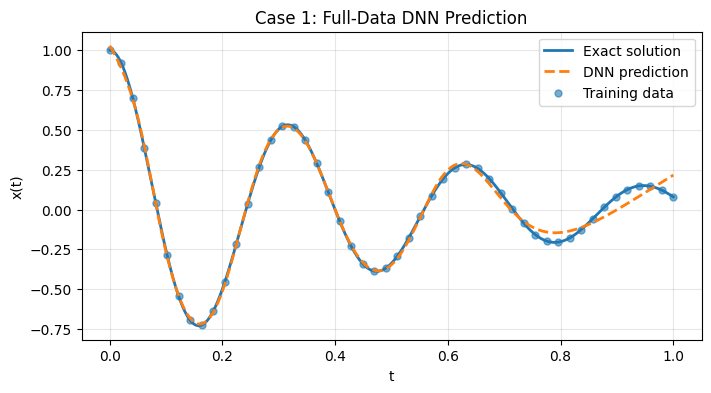

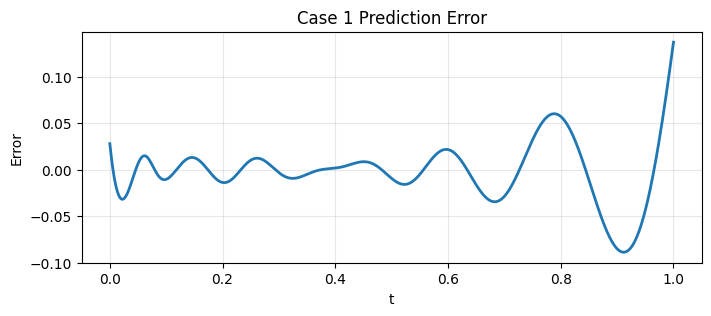

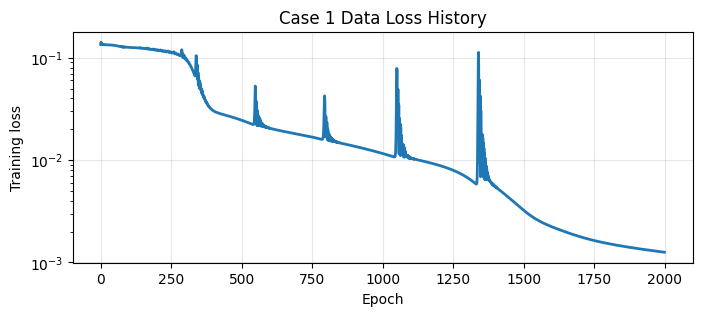

In [6]:
x_pred_case1 = predict(model_case1, t_full) # predicts on full t timeline

print("Case 1 DNN MSE on [0,1]:", mse_np(x_pred_case1, x_full))
print("Case 1 DNN max absolute error on [0,1]:", max_abs_error(x_pred_case1, x_full))

plt.figure(figsize=(8,4))
plt.plot(t_full, x_full, linewidth=2, label="Exact solution")
plt.plot(t_full, x_pred_case1, "--", linewidth=2, label="DNN prediction")
plt.scatter(t_train_np, x_train_np, s=25, alpha=0.6, label="Training data")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Case 1: Full-Data DNN Prediction")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8,3))
plt.plot(t_full, x_pred_case1 - x_full, linewidth=2)
plt.xlabel("t")
plt.ylabel("Error")
plt.title("Case 1 Prediction Error")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8,3))
plt.semilogy(history_case1, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Case 1 Data Loss History")
plt.grid(alpha=0.3)
plt.show()
